
# Step 1 - Khảo sát dữ liệu Wine Quality Red

Phần này đọc dữ liệu và kiểm tra các thông tin cơ bản theo yêu cầu của bài.

In [25]:
import pandas as pd

# Đọc file Excel
file_path = "../data/D09 - winequality-red.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="winequality-red"
)

# Xuất sang CSV
csv_path = "../data/D09 - winequality-red.csv"

df.to_csv(
    csv_path,
    index=False
)

print("Đã chuyển Excel sang CSV:", csv_path)

# Kiểm tra dữ liệu
df.head()

Đã chuyển Excel sang CSV: ../data/D09 - winequality-red.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 1a. Kích thước và chiều của dữ liệu

In [26]:
print("Kích thước:", df.shape)
print("Số chiều:", df.ndim)
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

Kích thước: (1599, 12)
Số chiều: 2
Số dòng: 1599
Số cột: 12


Dữ liệu có **1599 mẫu và 12 cột**. Trong đó có 11 cột thuộc tính và cột `quality` là nhãn.

### 1b. Kiểu dữ liệu của các thuộc tính

In [27]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Các thuộc tính đầu vào đều là dữ liệu số thực (`float64`), còn `quality` là số nguyên (`int64`).

### 1c. Số lượng mẫu của từng giá trị nhãn

In [28]:
label_counts = df["quality"].value_counts().sort_index()
label_counts

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Có 6 mức chất lượng từ 3 đến 8. Nhãn 5 và 6 có nhiều mẫu nhất, còn nhãn 3 và 8 có khá ít mẫu nên phân bố nhãn chưa cân bằng.

### 1d. Giá trị nhỏ nhất, lớn nhất và trung bình của các thuộc tính

In [29]:
features = df.drop(columns="quality")

statistics = features.agg(["min", "max", "mean"]).T
statistics.round(3)

,min,max,mean
fixed acidity,4.600,15.900,8.320
volatile acidity,0.120,1.580,0.528
citric acid,0.000,1.000,0.271
residual sugar,0.900,15.500,2.539
chlorides,0.012,0.611,0.087
free sulfur dioxide,1.000,72.000,15.875
total sulfur dioxide,6.000,289.000,46.468
density,0.990,1.004,0.997
pH,2.740,4.010,3.311
sulphates,0.330,2.000,0.658


Các thuộc tính có thang giá trị khá khác nhau. Ví dụ `density` có giá trị quanh 1, trong khi `total sulfur dioxide` có thể lớn hơn 200.

### Kiểm tra thêm: giá trị thiếu

In [30]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Không có giá trị thiếu trong bộ dữ liệu.

# Step 2 - TRỰC QUAN HÓA DỮ LIỆU


In [31]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sử dụng các thuộc tính của Step 1
X = features
y = df["quality"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)



Kích thước X: (1599, 11)
Kích thước y: (1599,)


In [32]:
# Chuẩn hóa dữ liệu và giảm số chiều = PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Kích thước sau PCA:", X_pca.shape)

Kích thước sau PCA: (1599, 2)


In [33]:
# Tạo DataFrsme mới
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["quality"] = y.values

df_pca.head()

,PC1,PC2,quality
0,-1.619530,0.450950,5
1,-0.799170,1.856553,5
2,-0.748479,0.882039,5
3,2.357673,-0.269976,6
4,-1.619530,0.450950,5


In [34]:
# Tỉ lệ phương sai giải thích bởi các thành phần chính
explained_variance = pca.explained_variance_ratio_

print(f"PC1: {explained_variance[0]:.4f}")
print(f"PC2: {explained_variance[1]:.4f}")
print(f"Tổng: {explained_variance.sum():.4f}")

PC1: 0.2817
PC2: 0.1751
Tổng: 0.4568


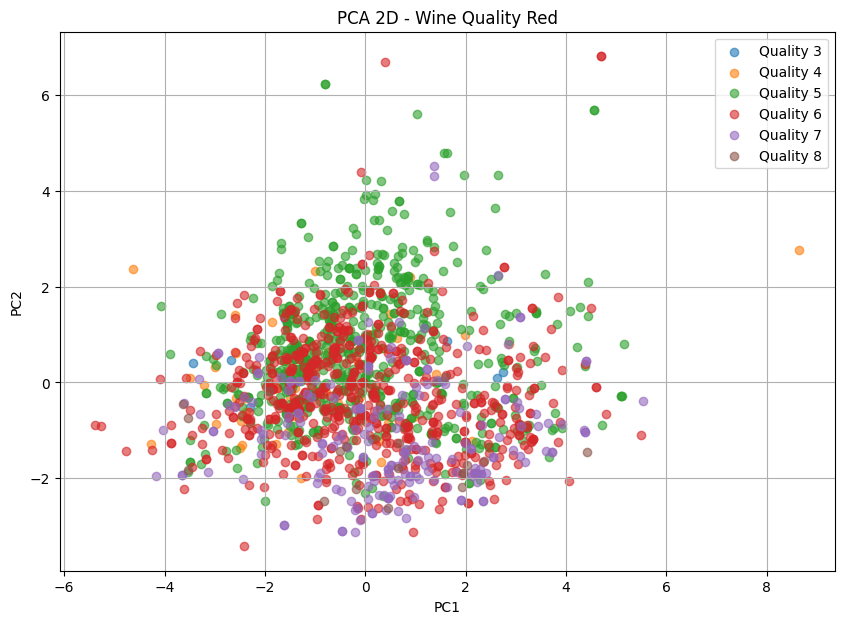

In [35]:
# Vẽ biểu đồ phân tán của dữ liệu sau khi giảm số chiều bằng PCA
plt.figure(figsize=(10, 7))

for quality in sorted(df_pca["quality"].unique()):
    data = df_pca[df_pca["quality"] == quality]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=f"Quality {quality}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D - Wine Quality Red")
plt.legend()
plt.grid(True)
plt.show()

# STEP 3 - PHÂN LỚP VÀ ĐÁNH GIÁ MÔ HÌNH

In [36]:
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Thiết lập Stratified 10 Fold
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

## Mô hình KNN

In [37]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

knn_grid.fit(X, y)

print("KNN - Best parameters:")
print(knn_grid.best_params_)
print("KNN - Best F1-Score:",
      round(knn_grid.best_score_, 4))



KNN - Best parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
KNN - Best F1-Score: 0.3679


## Mô hình Random Forest

In [38]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X, y)

print("\nRandom Forest - Best parameters:")
print(rf_grid.best_params_)
print("Random Forest - Best F1-Score:",
      round(rf_grid.best_score_, 4))



Random Forest - Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest - Best F1-Score: 0.3741


## Mô hình SVM

In [39]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

svm_params = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1],
    "model__kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

svm_grid.fit(X, y)

print("\nSVM - Best parameters:")
print(svm_grid.best_params_)
print("SVM - Best F1-Score:",
      round(svm_grid.best_score_, 4))


SVM - Best parameters:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
SVM - Best F1-Score: 0.3185


## So sánh 3 mô hình

### Bảng so sánh

In [40]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Random Forest",
        "SVM"
    ],
    "F1-Score": [
        knn_grid.best_score_,
        rf_grid.best_score_,
        svm_grid.best_score_
    ]
})

results["F1-Score"] = results["F1-Score"].round(4)

display(results)


,Model,F1-Score
0,KNN,0.3679
1,Random Forest,0.3741
2,SVM,0.3185


### Biểu đồ so sánh

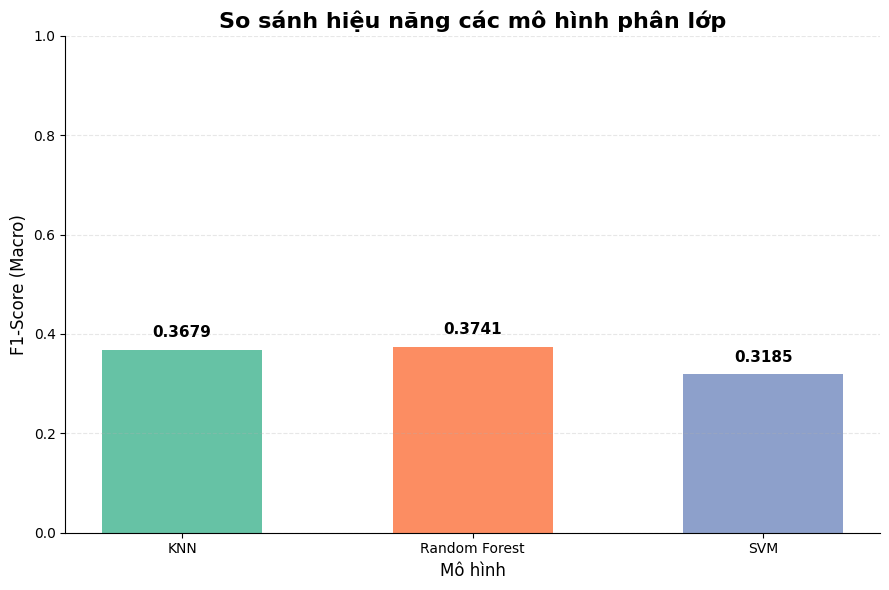

In [41]:
plt.figure(figsize=(9, 6))

models = results["Model"]
scores = results["F1-Score"]

# Tạo 3 màu khác nhau
colors = plt.cm.Set2([0, 1, 2])

bars = plt.bar(
    models,
    scores,
    color=colors,
    width=0.55
)

# Tiêu đề và nhãn
plt.title(
    "So sánh hiệu năng các mô hình phân lớp",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Mô hình",
    fontsize=12
)

plt.ylabel(
    "F1-Score (Macro)",
    fontsize=12
)

# Giới hạn trục Y
plt.ylim(0, 1)

# Hiển thị giá trị trên đầu mỗi cột
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Hiển thị grid nhẹ
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Không hiển thị đường viền phía trên và bên phải
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()